In [63]:
!pip install seaborn

In [64]:
# 🛳 Titanic Survival Prediction

#**Goal:** Predict probability of survival for Titanic passengers using Machine Learning.  
#Dataset: Kaggle “Titanic: Machine Learning from Disaster”.

#This notebook includes:
#- Data loading and exploration (EDA)
#- Cleaning and feature engineering
#- Logistic Regression baseline model
#- Optional Random Forest model
#- Model evaluation metrics
#- predict_survival()` function with examples

In [65]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [66]:
# Load dataset (update the path if needed)
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


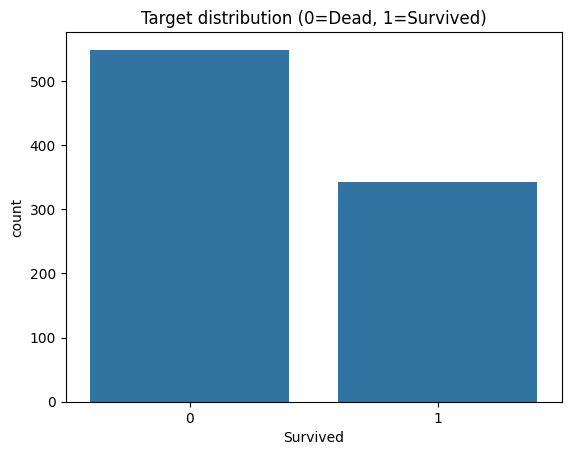

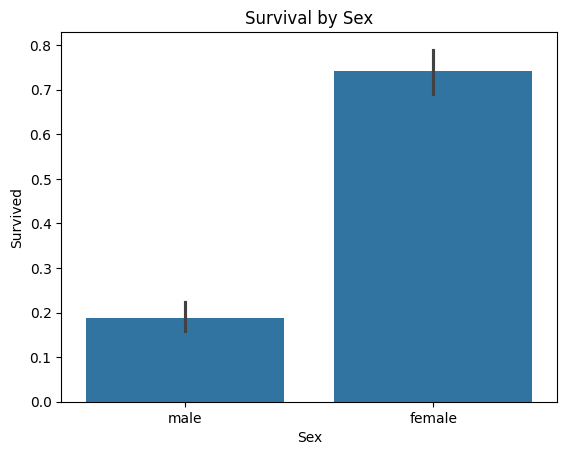

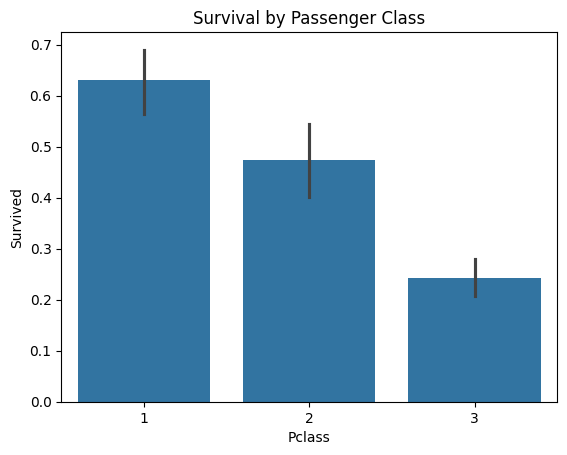

In [67]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Missing values
df.isnull().sum()

# Target distribution plot
sns.countplot(x='Survived', data=df)
plt.title("Target distribution (0=Dead, 1=Survived)")
plt.show()

# Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival by Sex")
plt.show()

# Survival by Pclass
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

In [68]:
# 1. Reload the dataset fresh (to restore the original data)
df = pd.read_csv("train.csv")

# 2. Check that 'Sex' looks normal
print(df['Sex'].unique())  # should show ['male' 'female']

# 3. Map to binary
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# 4. Check for NaN (should be 0)
print("NaN après mapping:", df['Sex'].isnull().sum())

# 5. If there are any missing (shouldn’t be), fill with mode
if df['Sex'].isnull().sum() > 0:
    df['Sex'].fillna(df['Sex'].mode()[0], inplace=True)

# 6. Verify result
print(df['Sex'].head(10))
print(df['Sex'].value_counts())


['male' 'female']
NaN après mapping: 0
0    1
1    0
2    0
3    0
4    1
5    1
6    1
7    1
8    0
9    0
Name: Sex, dtype: int64
Sex
1    577
0    314
Name: count, dtype: int64


In [69]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Verify no missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [70]:
print(df['Sex'].head(10))

0    1
1    0
2    0
3    0
4    1
5    1
6    1
7    1
8    0
9    0
Name: Sex, dtype: int64


In [55]:

# FamilySize: total family members aboard
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Extract passenger title (Mr, Miss, Mrs, etc.)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Normalize rare or similar titles
df['Title'] = df['Title'].replace(['Mlle', 'Ms', 'Mme'], 'Miss')
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
     'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other'
)

# is_child: flag passengers under 12 (handle NaN in Age safely)
df['is_child'] = ((df['Age'].fillna(99)) < 12).astype(int)

# Verify
df[['Name', 'Title', 'Sex', 'Age', 'FamilySize', 'is_child']].head(50)


,Name,Title,Sex,Age,FamilySize,is_child
0,"Braund, Mr. Owen Harris",Mr,1,22.0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,0,38.0,2,0
2,"Heikkinen, Miss. Laina",Miss,0,26.0,1,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,0,35.0,2,0
4,"Allen, Mr. William Henry",Mr,1,35.0,1,0
5,"Moran, Mr. James",Mr,1,28.0,1,0
6,"McCarthy, Mr. Timothy J",Mr,1,54.0,1,0
7,"Palsson, Master. Gosta Leonard",Master,1,2.0,5,1
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,0,27.0,3,0
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,0,14.0,2,0


In [56]:
## 🤖 Modeling: Logistic Regression
#Train a Logistic Regression model with selected features.

In [57]:
# Features and target
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

features = ['Pclass','Sex','Age','Fare','FamilySize','is_child']
X = df[features]
y = df['Survived']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# Train Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

# Predictions
y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Feature coefficients
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': model_lr.coef_[0]})
coefficients


NameError: name 'X_train' is not defined

In [15]:
## 🔮 Optional: Random Forest
Compare Logistic Regression with a tree-based model.

SyntaxError: invalid syntax (989158140.py, line 2)

In [16]:
# Train Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:,1]

# Metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC AUC:", roc_auc_score(y_test, y_proba_rf))

NameError: name 'X_train' is not defined

In [17]:
## 🧾 Predictor Function
Define `predict_survival()` function for new passenger data.

SyntaxError: invalid syntax (4140553593.py, line 2)

In [18]:
def predict_survival(pclass, sex, age, fare, family_size, is_child):
    """
    Return probability of survival (0-1) using Logistic Regression.
    sex: 0=female, 1=male
    is_child: 0=no, 1=yes
    """
    x_new = pd.DataFrame([[pclass, sex, age, fare, family_size, is_child]], columns=features)
    prob = model_lr.predict_proba(x_new)[0,1]
    return float(prob)

# Example predictions
print("Example 1:", predict_survival(1, 0, 60, 100, 1, 0))  # 1st class female
print("Example 2:", predict_survival(3, 1, 25, 15, 4, 0))   # 3rd class male
print("Example 3:", predict_survival(2, 0, 8, 20, 3, 1))    # 2nd class female child

NameError: name 'features' is not defined